# LangGraph - Multi Agent Collaboration

>Multi-Agent Network

To tackle complex tasks that span multiple domains, it’s often more effective to break the work down and let specialized agents handle different parts. Instead of relying on a single, all-purpose agent to manage everything, we can build a multi-agent network — a system where multiple agents, each with their own area of expertise, collaborate to solve problems.

In this chapter, we will design a simple system with two distinct agents: a research agent and a coding agent.

The research agent will handle tasks like searching for information or gathering data, while the coding agent will focus on generating and executing code, such as producing charts or visualizations.

![[text](https://github.com/langchain-ai/langgraph/blob/main/docs/docs/tutorials/multi_agent/multi-agent-collaboration.ipynb)](assets/img/12-agent-collab-1.webp)

The process is straightforward: a user submits a request, the research agent first investigates and gathers the necessary information, and then hands off the relevant details to the coding agent for final execution.

First, the imports:

In [23]:
from langchain_community.tools import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END, StateGraph, START
from langgraph.types import Command
from IPython.display import Image, display
from typing import Annotated, Literal
from dotenv import load_dotenv
load_dotenv()

True

To enable our agents to execute code as part of its workflow, we need to provide a way to agents to run Python scripts and return the results.

Let’s define a Python tool that serves as an interface to a Python REPL. This tool will accept code as input, execute it, and return the output.

In [24]:
# Initialize the Python REPL utility
repl = PythonREPL()

# Define a tool that executes Python code using the REPL
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

The decorator `@tool` registers this function as a LangChain tool, making it accessible within agent workflows.

Let’s instantiate an LLM and define a system prompt to use in agents.

In [25]:
llm = ChatOpenAI(model="gpt-4o")

The prompt sets the expectations for cooperation and signals how agents should respond when they reach a final answer.

In [26]:
def make_system_prompt(suffix: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

We then create a chart generator agent using the `create_react_agent` utility, equipping it only with the tools needed for chart creation.

In [27]:
# Create the chart-generating agent with its specific tool and prompt
chart_agent = create_react_agent(
    llm,
    [python_repl_tool],
    prompt=make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
)

/tmp/ipykernel_668746/1864780028.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent = create_react_agent(


Next, we define a node function for the chart agent. This function processes messages, determines if the task is complete, and packages up the state for the next agent or concludes the workflow.

In [28]:
# Function to determine the next step based on the agent's last message
def get_next_node(last_message: BaseMessage, goto: str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

Now, we can create the node for chart generation.

In [29]:
# Node function for chart agent
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = chart_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "researcher")
    # Ensure message compatibility for the next agent by wrapping as HumanMessage
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="chart_generator"
    )
    return Command(
        update={
            "messages": result["messages"],
        },
        goto=goto,
    )

To enable the research side, we set up a research agent powered by a search tool `TavilySearchResults`. This agent works in tandem with the chart generator.

In [30]:
# Instantiate the TavilySearchResults tool for online research
brave_tool = TavilySearchResults(max_results=5)

# Create the research agent with its dedicated tool and a collaborative system prompt
research_agent = create_react_agent(
    llm,
    tools=[brave_tool],
    prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)

# Define the node logic for the research agent
def research_node(
    state: MessagesState,
) -> Command[Literal["chart_generator", END]]:
    result = research_agent.invoke(state)
    goto = get_next_node(result["messages"][-1], "chart_generator")
    # Ensure message compatibility for the next agent by wrapping as HumanMessage
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="researcher"
    )
    return Command(
        update={
            # Share the agent's message history for context
            "messages": result["messages"],
        },
        goto=goto,
    )

/tmp/ipykernel_668746/718481435.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


The `research_node` function acts as the decision logic for this agent, passing control to the chart generator unless the task is marked complete with “FINAL ANSWER”.

Finally, let’s create and compile our graph.

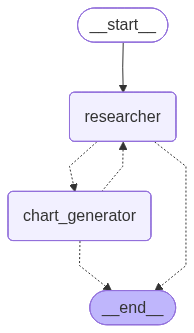

In [31]:
# Create the workflow graph, specifying the state type
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

# Set the starting point: researcher goes first
workflow.add_edge(START, "researcher")

# Compile the workflow graph
graph = workflow.compile()

# Visualize the workflow as a diagram
display(Image(graph.get_graph().draw_mermaid_png()))

Let’s execute it. It will research the UK’s GDP for the past 5 years and visualize it as a line chart.

We can stream the events produced by our workflow. This approach allows us to follow along as the agents interact, hand off tasks, and ultimately produce the final answer.

{'researcher': {'messages': [HumanMessage(content="First, get the UK's GDP over the past 5 years, then make a line chart of it. Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='ec14d961-2857-41d4-946d-8bbb29c1658a'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 208, 'total_tokens': 231, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_363ea47c38', 'id': 'chatcmpl-DMQtM3ReeHiDcxwYqVQvPrvUbeTU2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d18e0-7485-73f1-a740-3ca9589935a9-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'UK GDP last 5 years'}, 'id': 'c

Python REPL can execute arbitrary code. Use with caution.


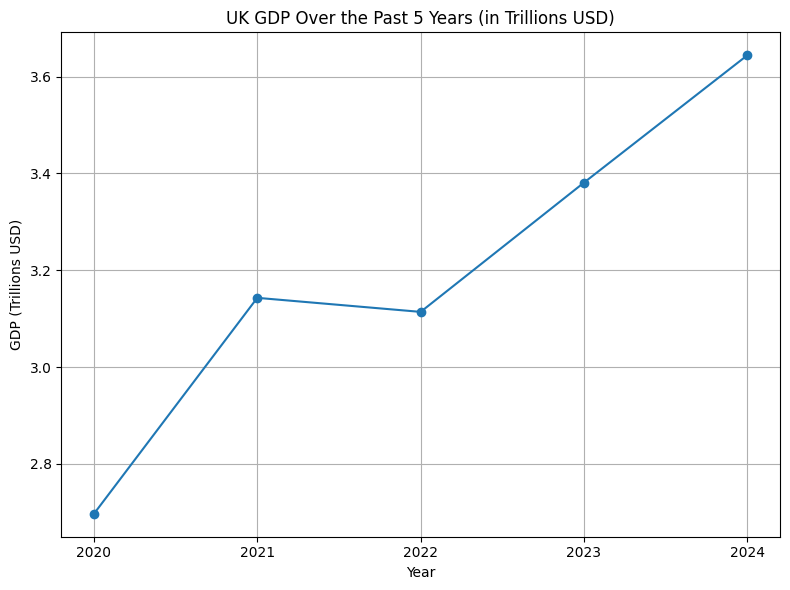

{'chart_generator': {'messages': [HumanMessage(content="First, get the UK's GDP over the past 5 years, then make a line chart of it. Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='ec14d961-2857-41d4-946d-8bbb29c1658a'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 208, 'total_tokens': 231, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_363ea47c38', 'id': 'chatcmpl-DMQtM3ReeHiDcxwYqVQvPrvUbeTU2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d18e0-7485-73f1-a740-3ca9589935a9-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'UK GDP last 5 years'}, 'id

In [32]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "First, get the UK's GDP over the past 5 years, then make a line chart of it. "
                "Once you make the chart, finish.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")

By streaming the workflow events, we get insight into how our multi-agent system delegates, executes, and communicates step by step, making it easier to debug, extend, or adapt for new use cases.

{'researcher': {'messages': [HumanMessage(content='Pesquise pela arrecadação de impostos do Ceará nos últimos 10 anos e faça um gráfico de linha com os resultados, detalhando os valores com labels para melhor leitura.Uma vez que o gráfico esteja pronto, finalize.', additional_kwargs={}, response_metadata={}, id='4ca85053-7337-4708-9bfd-bc28c3b5b9bd'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 224, 'total_tokens': 254, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_363ea47c38', 'id': 'chatcmpl-DMR4FLHSItADnhCQqsPNAoW6sa3Tm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d18ea-bf9c-7051-8649-6d65c179eaca-0'

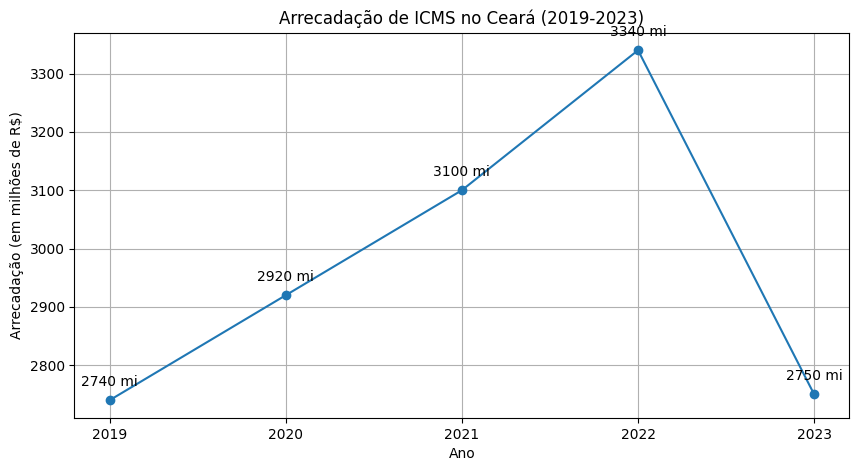

{'chart_generator': {'messages': [HumanMessage(content='Pesquise pela arrecadação de impostos do Ceará nos últimos 10 anos e faça um gráfico de linha com os resultados, detalhando os valores com labels para melhor leitura.Uma vez que o gráfico esteja pronto, finalize.', additional_kwargs={}, response_metadata={}, id='4ca85053-7337-4708-9bfd-bc28c3b5b9bd'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 224, 'total_tokens': 254, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_363ea47c38', 'id': 'chatcmpl-DMR4FLHSItADnhCQqsPNAoW6sa3Tm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d18ea-bf9c-7051-8649-6d65c179ea

In [34]:
events = graph.stream(
    {
        "messages": [
            (
                "user",
                "Pesquise pela arrecadação de impostos do Ceará nos últimos 10 anos e faça um gráfico de linha com os resultados, detalhando os valores com labels para melhor leitura."
                "Uma vez que o gráfico esteja pronto, finalize.",
            )
        ],
    },
    # Maximum number of steps to take in the graph
    {"recursion_limit": 150},
)
for s in events:
    print(s)
    print("----")